#### Preprocessing code

Code to convert MATLAB processing into Python

Created for dlx56_mPFC_1p_SohalLab repo
based off code in ruleshifting-inscopix private repo

#### Import packages


In [2]:
from __future__ import annotations
import os
from pathlib import Path
from datetime import datetime
from typing import List, Any, Dict
import numpy as np
import pandas as pd
import psutil
from functools import partial
from joblib import Parallel, delayed 
import notebook_setup
info = notebook_setup.setup()
# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
from concurrent.futures import ProcessPoolExecutor, as_completed

Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle


In [3]:
#import local yaml for env preset variables
from analysis_config_loader import load_analysis_config  # new import
config_path = "analysis_config.yaml"  # adjust as needed
analysis_config = load_analysis_config(config_path)

In [4]:
type(analysis_config)
analysis_config
stage_names = analysis_config.task_phase_names
stage_cols =  stage_names
stage_names


['Early_IA_Error',
 'Early_IA_Correct',
 'Late_IA',
 'Early_RS_Error',
 'Early_RS_Correct',
 'Late_RS']

#### Define dataset methods

In [5]:
#set parameters
data_type_used = "calcium_spikes" #OR, 'dff'
run_activity_enrichment = True
export_mean_active = True
use_WT_CLNZ_folder = False
phase_type = analysis_config.phase_division_types[1]  # 'complex', early vs late and correct vs error
print(phase_type)
# set up locations for input/output #get where to load data 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
print(root_dir)
os.chdir(root_dir)
data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')

#make analysis folder 
hour_str = datetime.now().strftime("%H")

storage_folder_name = root_dir / Path(f"processed_{data_type_used}")
print(storage_folder_name)
storage_folder_name.mkdir(parents=True, exist_ok=True)


complex
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\processed_calcium_spikes


In [6]:
## Matlab file handling functions:
import h5py

def check_corrupted_files(failed_files):
    # Optional Investigate corrupted files
    print("="*70)
    print("INVESTIGATING CORRUPTED FILES")
    print("="*70)

    if len(failed_files) == 0:
        print("No failed files to investigate.")
        return
    
    for fname in failed_files:
        filepath = source_dataset_location / fname
        
        print(f"\n📁 {fname}")
        print("-" * 70)
        
        if not filepath.exists():
            print("   File does not exist!")
            continue
        
        # Check file size
        size_bytes = filepath.stat().st_size
        size_kb = size_bytes / 1024
        size_mb = size_kb / 1024
        
        print(f"  Size: {size_bytes:,} bytes ({size_mb:.2f} MB)")
        
        # Read first bytes to check file signature
        with open(filepath, 'rb') as f:
            header = f.read(100)
        
        # Check for MATLAB file signatures
        print(f"  First 20 bytes (hex): {header[:20].hex()}")
        
        # HDF5 files should start with \x89HDF\r\n\x1a\n
        if header[:4] == b'\x89HDF':
            print("  ✓ Valid HDF5 signature")
        elif header[:4] == b'MATL':
            print("  ⚠️ Old MATLAB format (v5/v6) - needs scipy.io")
        else:
            print(f"   Unknown file signature - file may be corrupted")
            print(f"     Expected: b'\\x89HDF' or b'MATL'")
            print(f"     Got: {header[:4]}")
        
        # Try to detect if file is truncated
        if size_mb < 1:
            print(f"  ⚠️ WARNING: File is unusually small ({size_mb:.2f} MB)")

    # Compare with a working file
    print("\n" + "="*70)
    print("COMPARISON WITH WORKING FILES:")

    # Get file sizes of all working files
    working_sizes = []
    for obj in loaded_objects[:5]:
        fname = obj['name'] + '_dataset_object.mat'
        fpath = source_dataset_location / fname
        if fpath.exists():
            size_mb = fpath.stat().st_size / 1024 / 1024
            working_sizes.append(size_mb)
            print(f"  {fname}: {size_mb:.2f} MB")

    if working_sizes:
        avg_size = sum(working_sizes) / len(working_sizes)
        print(f"\n  Average working file size: {avg_size:.2f} MB")

def load_matlab_object(filepath):
    """Load MATLAB dataset_with_spatial_ROI object from .mat file"""
    # Parse metadata from filename
    filename = filepath.stem.replace('_dataset_object', '')
    parts = filename.split('_')
    
    # Extract name, geno from filename (e.g., "10_3_HET_RS1")
    name = filename
    if len(parts) >= 3:
        geno = parts[2]  # HET or WT
        session = parts[3] if len(parts) > 3 else 'RS1'
    else:
        geno = "UNKNOWN"
        session = "RS1"
    
    try:
        with h5py.File(filepath, 'r') as f:            # Load numeric data from known datasets
            raster = f['#refs#']['i'][()]  # (time, cells)
            # Get deduplicated flag from group x
            deduplicated = f['#refs#']['x']['deduplicated'][0, 0] if 'deduplicated' in f['#refs#']['x'] else False
            # Create object dictionary
            obj = {
                'name': name,
                'geno': geno,
                'session': session,
                'geno_day': None,  # Will need to be set externally if needed
                'raster': raster.T,  # Transpose to (cells, time)
                'deduplicated': bool(deduplicated),
                'good_cells': f['#refs#']['k'][()] if 'k' in f['#refs#'] else None,  # Cell IDs
                'labels': f['#refs#']['j'][()] if 'j' in f['#refs#'] else None,  # Trial/time info
            }
            # Load spatial info if present
            if 'n' in f['#refs#']:
                spatial = f['#refs#']['n']
                obj['spatial_weights'] = spatial['spatial_weights'][()] if 'spatial_weights' in spatial else None
                obj['temporal_weights'] = spatial['temporal_weights'][()] if 'temporal_weights' in spatial else None
                obj['user_labels'] = spatial['user_labels'][()] if 'user_labels' in spatial else None
                obj['subject_name'] = spatial['subject_name'][()] if 'subject_name' in spatial else None
            
            return obj
    
    except (OSError, KeyError) as e:
        print(f"  ERROR loading {filepath.name}: {e}")
        return None


In [7]:
#get all dataset names
#verify you are using the correct number of dataset 
source_dataset_location = Path(r"C:\Users\13car\Dropbox\UCSF\vikaas\Ruleshifting task notes\dlx mice notes\All datasets- Padded Labels, raster, EXTRACT outputs\dataset_objects")
content_names = [f for f in source_dataset_location.glob('**/*') if "object" in f.name]
print(f"Found {len(content_names)} files in {source_dataset_location}")
for file in content_names:
    print(file.name)

assert len(content_names) == 35, "Number of datasets does not match expected"

Found 35 files in C:\Users\13car\Dropbox\UCSF\vikaas\Ruleshifting task notes\dlx mice notes\All datasets- Padded Labels, raster, EXTRACT outputs\dataset_objects
10_3_HET_RS1_dataset_object.mat
10_3_HET_RS2_dataset_object.mat
10_3_HET_RS3_dataset_object.mat
13_3_HET_RS1_dataset_object.mat
13_3_HET_RS2_dataset_object.mat
13_3_HET_RS3_dataset_object.mat
13_4_WT_RS1_dataset_object.mat
13_4_WT_RS2_dataset_object.mat
13_5_HET_RS1_dataset_object.mat
13_5_HET_RS2_dataset_object.mat
13_5_HET_RS3_dataset_object.mat
13_6_WT_RS1_dataset_object.mat
13_6_WT_RS2_dataset_object.mat
13_8_HET_RS1_dataset_object.mat
13_8_HET_RS2_dataset_object.mat
13_8_HET_RS3_dataset_object.mat
14_2_WT_RS1_dataset_object.mat
14_2_WT_RS2_dataset_object.mat
15_1_HET_RS1_dataset_object.mat
15_1_HET_RS2_dataset_object.mat
15_1_HET_RS3_dataset_object.mat
5_3_WT_RS1_dataset_object.mat
5_3_WT_RS2_dataset_object.mat
6_2_WT_RS1_dataset_object.mat
6_2_WT_RS2_dataset_object.mat
7_2_WT_RS1_dataset_object.mat
7_4_WT_RS1_dataset_obje

In [8]:
# Load all files with error handling
loaded_objects = []
failed_files = []

for num, file in enumerate(content_names):
    print(f"Loading file {num}/{len(content_names)}: {file.name}")
    obj = load_matlab_object(file)
    if obj is None:
        failed_files.append(file.name)
        print(f"  SKIPPED\n")
        continue
    loaded_objects.append(obj)
    print(f"  {obj['name']}: {obj['raster'].shape[0]} cells × {obj['raster'].shape[1]} frames")
print(f"\n SUMMARY: Successfully loaded {len(loaded_objects)}/{len(content_names)} files")

if failed_files:
    print(f"\n Failed files ({len(failed_files)}):")
    for fname in failed_files:
        print(f"  - {fname}")
check_corrupted_files(failed_files)

Loading file 0/35: 10_3_HET_RS1_dataset_object.mat
  10_3_HET_RS1: 136 cells × 150415 frames
Loading file 1/35: 10_3_HET_RS2_dataset_object.mat
  10_3_HET_RS2: 168 cells × 97940 frames
Loading file 2/35: 10_3_HET_RS3_dataset_object.mat
  10_3_HET_RS3: 157 cells × 108794 frames
Loading file 3/35: 13_3_HET_RS1_dataset_object.mat
  13_3_HET_RS1: 160 cells × 191533 frames
Loading file 4/35: 13_3_HET_RS2_dataset_object.mat
  13_3_HET_RS2: 145 cells × 108651 frames
Loading file 5/35: 13_3_HET_RS3_dataset_object.mat
  13_3_HET_RS3: 147 cells × 128277 frames
Loading file 6/35: 13_4_WT_RS1_dataset_object.mat
  13_4_WT_RS1: 183 cells × 153831 frames
Loading file 7/35: 13_4_WT_RS2_dataset_object.mat
  13_4_WT_RS2: 171 cells × 106245 frames
Loading file 8/35: 13_5_HET_RS1_dataset_object.mat
  13_5_HET_RS1: 120 cells × 229350 frames
Loading file 9/35: 13_5_HET_RS2_dataset_object.mat
  13_5_HET_RS2: 125 cells × 141283 frames
Loading file 10/35: 13_5_HET_RS3_dataset_object.mat
  13_5_HET_RS3: 131 cel

<Axes: >

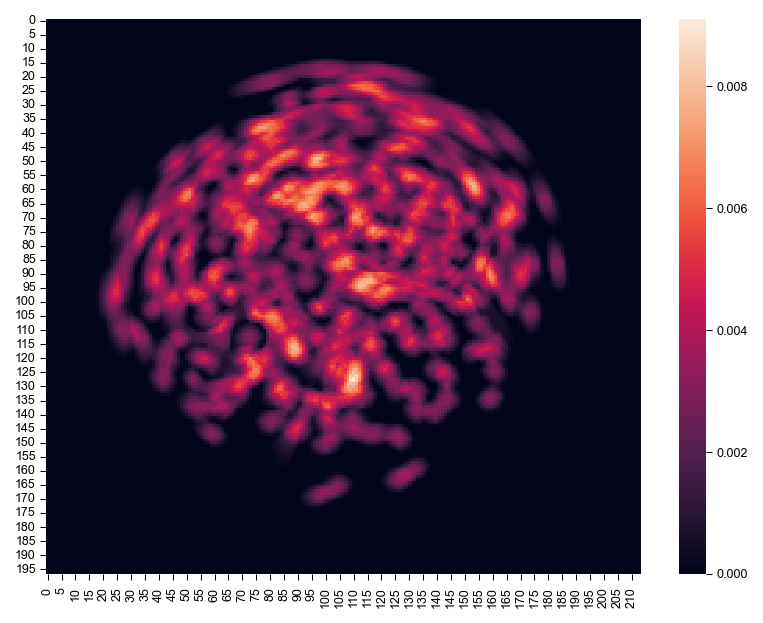

In [9]:
sns.heatmap(np.mean(obj['spatial_weights'], axis=0))

#### Import canonical dataset used in paper

In [10]:
# import canonical ensemble matrix previously created in MATLAB, used for paper #find old file- 
canonical_file = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet")
canonical_data = pd.read_parquet(canonical_file)
print(canonical_data.info())
canonical_data.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 93253 entries, 0 to 116376
Data columns (total 93 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   task_phase_vec     93253 non-null  object 
 1   IA_RS_vec          93253 non-null  object 
 2   corr_err_vec       93253 non-null  object 
 3   trial_num          93253 non-null  int64  
 4   neuron_ID          93253 non-null  int64  
 5   name               93253 non-null  object 
 6   day                93253 non-null  int32  
 7   geno               93253 non-null  object 
 8   geno_day           93253 non-null  object 
 9   -3.0s to -2.75s    93253 non-null  float64
 10  -2.75s to -2.5s    93253 non-null  float64
 11  -2.5s to -2.25s    93253 non-null  float64
 12  -2.25s to -2.0s    93253 non-null  float64
 13  -2.0s to -1.75s    93253 non-null  float64
 14  -1.75s to -1.5s    93253 non-null  float64
 15  -1.5s to -1.25s    93253 non-null  float64
 16  -1.25s to -1.0s    93253 n

,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,name,day,geno,geno_day,-3.0s to -2.75s,...,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,enriched_in_phase,any_enrichment,unique_ID,max_trial_val,mean_rate,active_in_trial
0,Early_IA_Correct,IA,Correct,1,1,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.0,False
2,Early_IA_Correct,IA,Correct,1,3,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-3,1.0,0.0,False
3,Early_IA_Correct,IA,Correct,1,4,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,1.0,0.0,0.0,False,1.0,10_3_HET_RS1-4,1.0,0.0,False


In [11]:
#get ensemble info from canon df
canon_ensembles  = canonical_data.groupby(by = ['unique_ID', 'geno', 'geno_day'])[stage_cols].first()
canon_ensembles.tail(3)

,,,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS
unique_ID,geno,geno_day,,,,,,
9_3_HET_RS3-97,HET,Het postCLNZ,1.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-98,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-99,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0


### Extract and Transform Matlab Objects into stage-labeled dataframes

#### E- dataset objs to dataframes, T- add task stage cols

In [12]:
def dataset_obj_to_df(dataset_obj):
    # Create DataFrame from raster (cells × frames)
    print(f"Processing {dataset_obj['name']}: {dataset_obj['raster'].nbytes} bytes")
    #setup dataset df 
    raster_df = pd.DataFrame(
        dataset_obj['raster'].T,
        index=[f'frame_{i}' for i in range(dataset_obj['raster'].shape[1])],
        columns = [f'cell_{i}' for i in range(dataset_obj['raster'].shape[0])],
        dtype = 'Sparse[int]')
            #add labels
    raster_df['labels'] = dataset_obj['labels']
    # Add metadata columns
    #cell Id is represented as col name 
    raster_df['subject_name'] = dataset_obj['name']
    raster_df['geno'] = dataset_obj['geno']
    raster_df['session'] = dataset_obj['session']
    
    return raster_df
#test 1 dataset
test_df = dataset_obj_to_df(loaded_objects[0])
print(test_df.info())
test_df.tail(3)

Processing 10_3_HET_RS1: 163651520 bytes
<class 'pandas.core.frame.DataFrame'>
Index: 150415 entries, frame_0 to frame_150414
Columns: 140 entries, cell_0 to session
dtypes: Sparse[int32, 0](136), float64(1), object(3)
memory usage: 12.5+ MB
None


,cell_0,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,...,cell_130,cell_131,cell_132,cell_133,cell_134,cell_135,labels,subject_name,geno,session
frame_150412,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1
frame_150413,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1
frame_150414,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1


In [13]:
from trial_detection import return_trial_num_at_frame, build_phase_masks, get_trial_stage_map, get_inRS_isError

def add_task_stage_to_raster_df(raster_df, analysis_config):
    """ Joins all the trial stage functions into one function for ease of use (function imported elsewhere).2s per raster 
    #workflow: 
        # 1) Call "trial num at frame" function
        # 2. Add trial number to raster_df
        # 3. drop frames that are not in a trial
        # 4. Add task stage to raster_df based off trial number at frame
    """
    stage_names = analysis_config.task_phase_names
    # 1. Transform frame label vector into trial vector
    labels = raster_df['labels']
    trial_num_at_frame, _, num_trials = return_trial_num_at_frame(labels)
    raster_df.loc[:, 'trial_num'] = trial_num_at_frame 

    # 2. Add trial number to raster_df
    raster_df = raster_df[raster_df['trial_num'] > 0].copy() #  dropping trial_num == 0
    # 4. Add task stage to raster_df based off trial number at frame
    stage_dict = build_phase_masks(labels,analysis_config)
    #5. map trial num to stage
    trial_stage_map = get_trial_stage_map(stage_dict, stage_names, num_trials)
    raster_df.loc[:, 'task_stage'] = raster_df['trial_num'].map(trial_stage_map)
    return raster_df

In [14]:
def label_frame_sections_df(df: pd.DataFrame, label_col: str,*, section_names=("pre_outcome", "post_outcome", "ITI")):
    """
    Vectorized: assign each frame one of {pre_outcome, post_outcome, ITI}. Tie-breaks at 4 (IA) and 11 (RS) go to post_outcome (overwrite order).

    Parameters
    ----------
    df : DataFrame with one row per frame
    label_col : name of column holding per-frame integer labels
    section_names : (pre_outcome, post_outcome, ITI)

    Returns
    -------
    pd.Series (object) of section names aligned to df.index
    """
    pre_outcome, post_outcome, iti = section_names
    labels = df[label_col].to_numpy()
    out = np.full(labels.shape[0], None, dtype=object)

    # IA ranges (2–8)
    ia_pre  = (labels >= 2)  & (labels <= 4)     # pre_outcome
    ia_post = (labels >= 4)  & (labels <= 7)     # post_outcome (overwrites label==4)
    ia_iti  = (labels == 8)                      # ITI

    # RS ranges (9–15)
    rs_pre  = (labels >= 9)  & (labels <= 11)    # pre_outcome
    rs_post = (labels >= 11) & (labels <= 14)    # post_outcome (overwrites label==11)
    rs_iti  = (labels == 15)                     # ITI

    # Overwrite order preserves “boundary goes to later section”:
    out[ia_pre  | rs_pre]  = pre_outcome
    out[ia_post | rs_post] = post_outcome
    out[ia_iti  | rs_iti]  = iti

    return out

In [15]:
# Loop over imported subject rasters and create pandas DataFrames
raster_dataframes = {}

for obj in loaded_objects:    # Create DataFrame from raster (cells × frames)
    raster_df = dataset_obj_to_df(obj)
    raster_df = add_task_stage_to_raster_df(raster_df, analysis_config)
    raster_df['trial_section'] = label_frame_sections_df(raster_df, 'labels', section_names=analysis_config.trial_section_names) #annotate pre,post,ITI

    raster_dataframes[obj['name']] = raster_df
print(f"\nTotal DataFrames created: {len(raster_dataframes)}")

Processing 10_3_HET_RS1: 163651520 bytes
Processing 10_3_HET_RS2: 131631360 bytes
Processing 10_3_HET_RS3: 136645264 bytes
Processing 13_3_HET_RS1: 245162240 bytes
Processing 13_3_HET_RS2: 126035160 bytes
Processing 13_3_HET_RS3: 150853752 bytes
Processing 13_4_WT_RS1: 225208584 bytes
Processing 13_4_WT_RS2: 145343160 bytes
Processing 13_5_HET_RS1: 220176000 bytes
Processing 13_5_HET_RS2: 141283000 bytes
Processing 13_5_HET_RS3: 101650760 bytes
Processing 13_6_WT_RS1: 407216056 bytes
Processing 13_6_WT_RS2: 286371552 bytes
Processing 13_8_HET_RS1: 205506288 bytes
Processing 13_8_HET_RS2: 184071712 bytes
Processing 13_8_HET_RS3: 247363296 bytes
Processing 14_2_WT_RS1: 158077680 bytes
Processing 14_2_WT_RS2: 170570944 bytes
Processing 15_1_HET_RS1: 209435040 bytes
Processing 15_1_HET_RS2: 185898360 bytes
Processing 15_1_HET_RS3: 133253480 bytes
Processing 5_3_WT_RS1: 198030360 bytes
Processing 5_3_WT_RS2: 211466640 bytes
Processing 6_2_WT_RS1: 212864136 bytes
Processing 6_2_WT_RS2: 19240

#### T- add task stage + metadata to subject dfs

In [16]:
raster_df

,cell_0,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,...,cell_212,cell_213,cell_214,labels,subject_name,geno,session,trial_num,task_stage,trial_section
frame_15007,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15008,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15009,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15010,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15011,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frame_205895,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205896,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205897,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205898,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI


In [17]:
def plot_task_stages(stage_dict, stage_cols, fig_size = (10, 7)):
    # Define stage_cols from the stage_dict keys (excluding internal keys starting with '_')
    stage_cols = [k for k in stage_dict.keys() if not k.startswith('_')]
    # Fix variable name: use 'axes' consistently, and squeeze data to handle shape (38,1) -> (38,)
    fig, axes = plt.subplots(len(stage_cols), 1, figsize = fig_size, layout = 'constrained')
    for index, s in enumerate(stage_cols):
        # Reshape to column vector for proper heatmap display
        data =  stage_dict[s].reshape(1, -1)
        sns.heatmap(ax = axes[index], data = data, cbar = False,  cmap = 'viridis')
        axes[index].set_title(s)



In [18]:

print(raster_df.trial_section.unique())
print(raster_df.task_stage.unique())
raster_df

['pre_outcome' 'post_outcome' 'ITI' None]
['Early_IA_Correct' 'Early_IA_Error' 0 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']


,cell_0,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,...,cell_212,cell_213,cell_214,labels,subject_name,geno,session,trial_num,task_stage,trial_section
frame_15007,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15008,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15009,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15010,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15011,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frame_205895,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205896,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205897,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205898,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI


### Run activity enrichment analysis

### Circular shuffle of frame labels 

In [19]:
## given task stage, create N label permuted versions and 

# matlab code flow:
# + create matrix (n_cells x N_shuffles), where elem at (i,j) = random frame offset for cell i at shuffle j 
# + for each shuffle, apply offset to (frame labels of interest) vector, with cells having independent offsets 
# + for each cell, calculate mean activity in offset frames 
# + calculate p-value for each cell

In [20]:
def get_frames_of_interest(raster_df, trial_section= 'post_outcome', task_stage= 'Late_RS'):
    """ Returns frames of interest for specific trial section (e.g. pre, post, ITI) and specific task stage (e.g. Late RS,or IA) """
    # bool_frames_of_interest : boolean series, with index = string of frame number and true if frame is of interest    
    bool_frames_of_interest = (raster_df['trial_section'] == trial_section) & (raster_df['task_stage'] == task_stage)
    # reset index to be numeric vals only, referencing what row in raster_df the bool_frames_of_interest are in
    bool_index_of_interest = bool_frames_of_interest.reset_index(drop = True)
    #use boolean indexing to get the row indices of the true values
    indices_of_true_values = bool_index_of_interest[bool_index_of_interest.values].index.values
    return indices_of_true_values


    

In [21]:
raster_df

,cell_0,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,...,cell_212,cell_213,cell_214,labels,subject_name,geno,session,trial_num,task_stage,trial_section
frame_15007,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15008,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15009,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15010,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15011,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frame_205895,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205896,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205897,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205898,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI


In [22]:
bool_frames_of_interest = get_frames_of_interest(raster_df)
bool_frames_of_interest

array([171860, 171861, 171862, ..., 187417, 187418, 187419], dtype=int64)

In [23]:
# I want to take the indices of the true values which == the right task stage x trial section combo, which will be the indices of the frames of interest.
bool_frames_of_interest
# 
# idea- predefine matrix of 1 constant rnadom int per column, add the frames of interest values to each column, that creates new index values for shuffle N 

array([171860, 171861, 171862, ..., 187417, 187418, 187419], dtype=int64)

In [24]:
## for testing
label_col = 'task_stage'
category_value = 'Early_IA_Correct'

# Convert to numpy arrays
cell_col = [c for c in raster_df.columns if 'cell' in c] #select all columns that contain 'cell'

#set lengths
n_frames_category = len(bool_frames_of_interest)
n_frames_total = len(raster_df)
print(n_frames_total)
n_cells = len(cell_col)   
#set floor of circular movement 
start_frame = np.min(bool_frames_of_interest)
max_frame = np.max(bool_frames_of_interest)
floor = -start_frame #allows circular shift to roll back to row 0 of matrix
ceiling = n_frames_total - max_frame
print(floor, ceiling)
# Generate all random shifts at once
#note, in MATLAB script, circularly shifted across entire matrix, not trial sections of interest
#note- 1 random shift per cell, per shuffle
shifts = np.random.randint(low = floor, high = ceiling, size=(1, n_cells)) #(low, high=None, size=None, dtype=int)
print(shifts.shape)
print(shifts)
    

190893
-171860 3474
(1, 215)
[[-117510 -149243  -36436   -8398 -154433  -13571  -57896  -70159 -131783
  -102000  -61781   -7608  -96069  -56923   -7976  -24982  -84953  -33003
  -100655 -139864  -37297 -171842  -64048   -6504  -61335  -86931  -91221
  -157057   -3464  -68412   -7319     380 -132356  -68824 -119895 -169451
    -3944  -13143 -100806   -5213  -19842  -54522  -17034 -105960  -16297
   -79693 -100018   -5428  -29766 -160942 -127610  -32923 -117951  -83764
  -146849  -84313  -80388  -39611  -78574  -45852   -9303 -145400 -134274
   -30966  -59881  -87698 -105567  -27225 -133905 -171167 -170697  -50229
  -109716 -107922 -110722 -127569 -148190  -30059  -43171 -163766 -104668
  -138095  -20554  -73086  -50285  -99965  -21430  -44056  -40419 -159801
  -117426  -28477  -40385  -60584 -128450  -89110 -120507 -149389  -38283
   -73945 -132504 -117530  -74162  -12512  -51152 -134140 -126820 -109210
   -63429  -90836  -83070     981 -129352 -122798  -56028 -156309 -117952
   -66966

In [25]:
def random_roll_columns(matrix, max_shift=None, random_seed=None):
    """
    Roll each column up or down by a random amount.
    Parameters:
    matrix (np.ndarray): 2D input array (rows × columns)
    max_shift (int, optional): Maximum shift amount. If None, uses row count.
    random_seed (int, optional): For reproducible results.
    
    Returns:
    np.ndarray: Matrix with each column rolled independently.
    """
    if random_seed is not None:
        rng = np.random.default_rng(random_seed)
    else:
        rng = np.random.default_rng()
    
    n_rows, n_cols = matrix.shape
    if max_shift is None:
        max_shift = n_rows
    
    # Generate one random shift per column
    shifts = rng.integers(-max_shift, max_shift + 1, size=n_cols)
    # Create row indices for each column
    rows = np.arange(n_rows)[:, np.newaxis]  # Column vector of row indices    
    # Apply shifts with wrapping
    shifted_indices = (rows - shifts) % n_rows #if the shift size is > than the number of rows, it will wrap 
    # Use advanced indexing to get the rolled matrix
    return matrix[shifted_indices, np.arange(n_cols)]
 

#### test col rolling 

In [26]:

mat = np.arange(1, 10)[:, np.newaxis] + np.zeros(10, dtype=int)
print("Original matrix:")
print(mat)

rolled = random_roll_columns(mat,random_seed = None)
print("\nAfter random column rolling:")
print(rolled)

Original matrix:
[[1 1 1 1 1 1 1 1 1 1]
 [2 2 2 2 2 2 2 2 2 2]
 [3 3 3 3 3 3 3 3 3 3]
 [4 4 4 4 4 4 4 4 4 4]
 [5 5 5 5 5 5 5 5 5 5]
 [6 6 6 6 6 6 6 6 6 6]
 [7 7 7 7 7 7 7 7 7 7]
 [8 8 8 8 8 8 8 8 8 8]
 [9 9 9 9 9 9 9 9 9 9]]

After random column rolling:
[[8 8 4 9 4 4 5 2 9 1]
 [9 9 5 1 5 5 6 3 1 2]
 [1 1 6 2 6 6 7 4 2 3]
 [2 2 7 3 7 7 8 5 3 4]
 [3 3 8 4 8 8 9 6 4 5]
 [4 4 9 5 9 9 1 7 5 6]
 [5 5 1 6 1 1 2 8 6 7]
 [6 6 2 7 2 2 3 9 7 8]
 [7 7 3 8 3 3 4 1 8 9]]


Text(0.5, 1.0, 'Rolled Data')

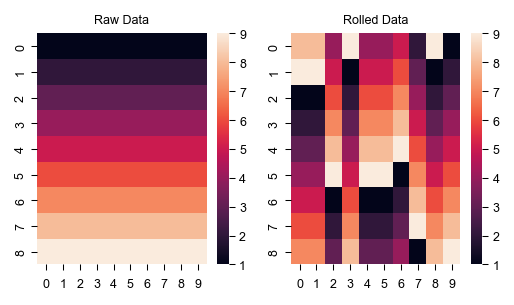

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(4, 2))
sns.heatmap(ax = axes[0], data = mat)
axes[0].set_title('Raw Data')

sns.heatmap(ax = axes[1], data = rolled)
axes[1].set_title('Rolled Data')


In [28]:
# Convert all sparse columns to dense (do this once)
for col in cell_col:
    if isinstance(raster_df[col].dtype, pd.SparseDtype):
        raster_df[col] = raster_df[col].sparse.to_dense()
raster_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 190893 entries, frame_15007 to frame_205899
Columns: 222 entries, cell_0 to trial_section
dtypes: float64(1), int32(216), object(5)
memory usage: 167.5+ MB


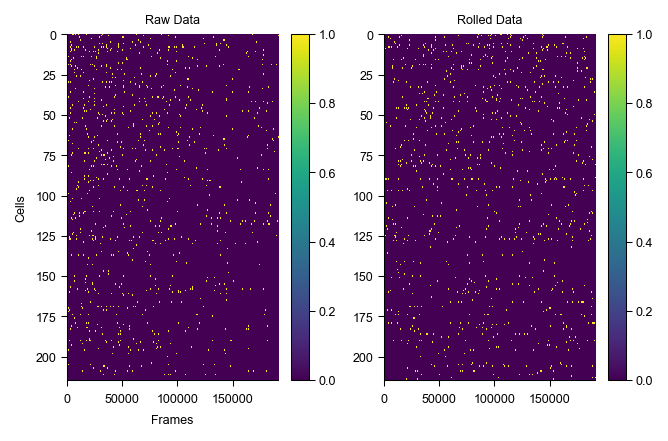

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(5, 3))
# Use imshow instead of seaborn heatmap for large data
im = axes[0].imshow(raster_df[cell_col].values.T, aspect='auto', cmap='viridis', interpolation='nearest')
axes[0].set_title('Raw Data')
axes[0].set_xlabel('Frames')
axes[0].set_ylabel('Cells')
plt.colorbar(im, ax=axes[0])

# For the rolled data
data = raster_df.loc[:, cell_col].values
roll_data = random_roll_columns(data)
im2 = axes[1].imshow(roll_data.T, aspect='auto', cmap='viridis', interpolation='nearest')
axes[1].set_title('Rolled Data')
plt.colorbar(im2, ax=axes[1])


In [30]:
def get_mean_postoutcome_stage_activity(input_df, cell_col, label_col='task_stage', section_col = 'trial_section', post_outcome_label='post_outcome'):
    """ For groupby operation that returns mean activity for post-outcome stage of each cell in each section """
    mean_section_stage_act = input_df.groupby(by = [label_col, section_col])[cell_col].mean() #325 ms
    return mean_section_stage_act.loc[(slice(None),post_outcome_label),:]    
def create_shuffled_df(args):
    """Helper function for parallel processing"""
    df, cell_col, random_seed = args
    roll_data = random_roll_columns(df[cell_col].values, random_seed= random_seed)
    rolled_df = pd.DataFrame(roll_data, columns=cell_col, index=df.index).join(df.drop(columns = cell_col))
    mean_section_stage_act = get_mean_postoutcome_stage_activity(rolled_df, cell_col)
    #new- 11.8.25- add shuffle seed record 
    mean_section_stage_act['shuffle_seed'] = random_seed
    return mean_section_stage_act

# 1s per shuffle is current speed

In [ ]:
run_shuffles = False  #set to True to run shuffles
# Option 1: Global seed sequence across all subjects
# This ensures no seed overlap between subjects

#16 physical cores to use 
total_cpu_physical = psutil.cpu_count(logical=False)
print(total_cpu_physical)
n_jobs= total_cpu_physical-2

# Configuration
n_shuf_per_subject = 1000
base_seed = 42
n_subjects = len(raster_dataframes)

# Generate global seed sequence
total_shuffles = n_subjects * n_shuf_per_subject
global_seeds = [base_seed + i for i in range(total_shuffles)]

print(f"Total subjects: {n_subjects}")
print(f"Shuffles per subject: {n_shuf_per_subject}")
print(f"Total shuffles: {total_shuffles}")
print(f"Seed range: {global_seeds[0]} to {global_seeds[-1]}")
if run_shuffles:
    # Process each subject with their allocated seed range
    all_subject_shuffles = {}

    for subject_idx, (subject_name, subject_raster_df) in enumerate(raster_dataframes.items()):
        print(f"\nProcessing subject {subject_idx+1}/{n_subjects}: {subject_name}")
        
        # Get cell columns for this subject
        cell_col = [c for c in subject_raster_df.columns if 'cell' in c]
        
        # Allocate unique seed range for this subject
        start_seed_idx = subject_idx * n_shuf_per_subject
        end_seed_idx = start_seed_idx + n_shuf_per_subject
        subject_seeds = global_seeds[start_seed_idx:end_seed_idx]
        
        print(f"  Seed range: {subject_seeds[0]} to {subject_seeds[-1]}")
        print(f"  Cells: {len(cell_col)}, Frames: {len(subject_raster_df)}")
        
        # Run parallel shuffles for this subject- oputputs lists
        output_shuff = Parallel(n_jobs=n_jobs, backend="loky", verbose=9)(
            delayed(create_shuffled_df)((subject_raster_df, cell_col, int(seed))) 
            for seed in subject_seeds)
        all_shuffle_means = pd.concat(output_shuff).drop(0).reset_index('trial_section', drop = True)

        all_shuffle_means['subject_name'] = subject_name #add shuffle names to each df in output_shuff
        all_subject_shuffles[subject_name] = all_shuffle_means
        print(f"  Completed {len(output_shuff)} shuffles")
        

    print(f"\n✓ All {n_subjects} subjects processed with unique seed ranges")


16
Total subjects: 35
Shuffles per subject: 1000
Total shuffles: 35000
Seed range: 42 to 35041

Processing subject 1/35: 10_3_HET_RS1
  Seed range: 42 to 1041
  Cells: 136, Frames: 135487


[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done   4 tasks      | elapsed:   13.8s
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:   20.4s
[Parallel(n_jobs=14)]: Done  44 tasks      | elapsed:   29.0s
[Parallel(n_jobs=14)]: Done  70 tasks      | elapsed:   39.3s
[Parallel(n_jobs=14)]: Done 100 tasks      | elapsed:   50.7s
[Parallel(n_jobs=14)]: Done 134 tasks      | elapsed:  1.1min
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:  1.3min
[Parallel(n_jobs=14)]: Done 214 tasks      | elapsed:  1.6min
[Parallel(n_jobs=14)]: Done 260 tasks      | elapsed:  1.9min
[Parallel(n_jobs=14)]: Done 310 tasks      | elapsed:  2.2min
[Parallel(n_jobs=14)]: Done 364 tasks      | elapsed:  2.5min
[Parallel(n_jobs=14)]: Done 422 tasks      | elapsed:  2.8min
[Parallel(n_jobs=14)]: Done 484 tasks      | elapsed:  3.2min
[Parallel(n_jobs=14)]: Done 550 tasks      | elapsed:  3.6min
[Parallel(n_jobs=14)]: Done 620 tasks      | elapsed:  

  Completed 1000 shuffles

Processing subject 2/35: 10_3_HET_RS2
  Seed range: 1042 to 2041
  Cells: 168, Frames: 85240


[Parallel(n_jobs=14)]: Done   4 tasks      | elapsed:    2.4s
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    7.3s
[Parallel(n_jobs=14)]: Done  44 tasks      | elapsed:   12.5s
[Parallel(n_jobs=14)]: Done  70 tasks      | elapsed:   20.7s
[Parallel(n_jobs=14)]: Done 100 tasks      | elapsed:   24.6s
[Parallel(n_jobs=14)]: Done 134 tasks      | elapsed:   28.1s
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:   31.4s
[Parallel(n_jobs=14)]: Done 214 tasks      | elapsed:   35.5s
[Parallel(n_jobs=14)]: Done 260 tasks      | elapsed:   39.5s
[Parallel(n_jobs=14)]: Done 310 tasks      | elapsed:   44.2s
[Parallel(n_jobs=14)]: Done 364 tasks      | elapsed:   48.6s
[Parallel(n_jobs=14)]: Done 422 tasks      | elapsed:   53.2s
[Parallel(n_jobs=14)]: Done 484 tasks      | elapsed:   57.8s
[Parallel(n_jobs=14)]: Done 550 tasks      | elapsed:  1.0min
[Parallel(n_jobs=14)]: Done 620 tasks      | elapsed:  1.1min
[Parallel(n_jobs=14)]: Done 694 tasks      | elapsed:  1.2min
[Paralle

  Completed 1000 shuffles

Processing subject 3/35: 10_3_HET_RS3
  Seed range: 2042 to 3041
  Cells: 157, Frames: 90423


...

[Parallel(n_jobs=14)]: Done   4 tasks      | elapsed:    1.2s
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    3.3s
[Parallel(n_jobs=14)]: Done  44 tasks      | elapsed:    5.8s
[Parallel(n_jobs=14)]: Done  70 tasks      | elapsed:    8.8s
[Parallel(n_jobs=14)]: Done 100 tasks      | elapsed:   12.3s
[Parallel(n_jobs=14)]: Done 134 tasks      | elapsed:   16.4s
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:   20.8s
[Parallel(n_jobs=14)]: Done 214 tasks      | elapsed:   25.5s
[Parallel(n_jobs=14)]: Done 260 tasks      | elapsed:   30.8s
[Parallel(n_jobs=14)]: Done 310 tasks      | elapsed:   36.3s
[Parallel(n_jobs=14)]: Done 364 tasks      | elapsed:   42.6s
[Parallel(n_jobs=14)]: Done 422 tasks      | elapsed:   49.2s
[Parallel(n_jobs=14)]: Done 484 tasks      | elapsed:   56.3s
[Parallel(n_jobs=14)]: Done 550 tasks      | elapsed:  1.1min
[Parallel(n_jobs=14)]: Done 620 tasks      | elapsed:  1.2min
[Parallel(n_jobs=14)]: Done 694 tasks      | elapsed:  1.3min
[Paralle

  Completed 1000 shuffles

Processing subject 35/35: 9_3_HET_RS3
  Seed range: 34042 to 35041
  Cells: 215, Frames: 190893


[Parallel(n_jobs=14)]: Done   4 tasks      | elapsed:    4.7s
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:   18.0s
[Parallel(n_jobs=14)]: Done  44 tasks      | elapsed:   34.6s
[Parallel(n_jobs=14)]: Done  70 tasks      | elapsed:   54.9s
[Parallel(n_jobs=14)]: Done 100 tasks      | elapsed:  1.3min
[Parallel(n_jobs=14)]: Done 134 tasks      | elapsed:  2.0min
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:  2.5min
[Parallel(n_jobs=14)]: Done 214 tasks      | elapsed:  3.1min
[Parallel(n_jobs=14)]: Done 260 tasks      | elapsed:  3.7min
[Parallel(n_jobs=14)]: Done 310 tasks      | elapsed:  4.3min
[Parallel(n_jobs=14)]: Done 364 tasks      | elapsed:  5.0min
[Parallel(n_jobs=14)]: Done 422 tasks      | elapsed:  5.7min
[Parallel(n_jobs=14)]: Done 484 tasks      | elapsed:  6.9min
[Parallel(n_jobs=14)]: Done 550 tasks      | elapsed:  7.7min
[Parallel(n_jobs=14)]: Done 620 tasks      | elapsed:  8.6min
[Parallel(n_jobs=14)]: Done 694 tasks      | elapsed:  9.5min
[Paralle

  Completed 1000 shuffles

✓ All 35 subjects processed with unique seed ranges


[Parallel(n_jobs=14)]: Done 1000 out of 1000 | elapsed: 13.4min finished


In [36]:
## save all shuffles as parquet file: 
# import pyarrow

for subject_name, output_shuff in all_subject_shuffles.items():

    #in case it was skipped last run, save name as col in df before parquet export
    output_shuff['subject_name'] = subject_name
    parquet_path = storage_folder_name / Path(f"{subject_name}_shuffled_mean_activity.parquet")
    output_shuff.to_parquet(parquet_path)   

TypeError: list indices must be integers or slices, not str

In [39]:
len(output_shuff)

1000

In [32]:

def get_cell_stage_enrichment(all_shuffle_means, raster_df, cell_col, n_shuf_per_subject):
    ## code for enrichment analysis: 

    #given N shuffles, find the 95th percentile value for each cell at each task stage
    cell_threshold = all_shuffle_means.groupby('task_stage')[cell_col].agg(lambda x: np.percentile(x, 95)) #empirical?

    #get real raster mean activity data (DESPARSIFY if necessary)
    for col in cell_col:
        if isinstance(raster_df[col], pd.SparseDtype):
            raster_df.loc[:, col] = raster_df[col].sparse.to_dense()
    #group real data by trial_section and task_stage
    real_mean_activity = raster_df.groupby(by = ['trial_section', 'task_stage'])[cell_col].mean().loc['post_outcome', (slice(None))].drop(0)

    #get % of shuffle values greater than or equal to real cell activity
    counts_per_cell = []
    for stage, group in all_shuffle_means.groupby("task_stage"):
        print(f"checking {stage}")
        real_values = real_mean_activity.loc[stage, cell_col] #get % of shuffle greater than or equal to real
        comparison = group[cell_col] >= real_values      # broadcast columnwise
        counts = comparison.sum()                         # count True per cell
        counts.name = stage                               # label this row
        counts_per_cell.append(counts)
    shuf_percentile = pd.DataFrame(counts_per_cell)/n_shuf_per_subject

    #get boolean mask of enriched cells
    enriched_cells = (real_mean_activity > cell_threshold)

    # melt dataframes for joining analysis
    shuf_percentile_long = shuf_percentile.reset_index().melt(id_vars = 'index', var_name = 'cell', value_name = r'percent_shuffle >= real').rename(columns = {'index': 'task_stage'})
    cell_enrich_long = enriched_cells.reset_index().melt(id_vars = 'task_stage', var_name = 'cell', value_name = 'enriched') #cells activity > threshold
    cell_activity_long = real_mean_activity.reset_index().melt(id_vars = 'task_stage', var_name = 'cell', value_name = 'mean') #real mean activity of cells
    cell_thresh_long = cell_threshold.reset_index().melt(id_vars = 'task_stage', var_name = 'cell', value_name = 'percentile_95') #95th percentile of shuffles

    #join dataframes
    cell_ensemble_info = pd.merge(pd.merge(cell_thresh_long, cell_activity_long, on=['task_stage','cell']), cell_enrich_long, on=['task_stage','cell'])
    cell_ensemble_info = pd.merge(cell_ensemble_info, shuf_percentile_long, on=['task_stage','cell'])
    return cell_ensemble_info

In [33]:
# get shuffle data percentiles
all_shuffle_means = pd.concat(output_shuff).drop(0).reset_index('trial_section', drop = True)

get_cell_stage_enrichment(all_shuffle_means, raster_df, cell_col, n_shuf_per_subject)

checking Early_IA_Correct
checking Early_IA_Error
checking Early_RS_Correct
checking Early_RS_Error
checking Late_IA
checking Late_RS


,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real
0,Early_IA_Correct,cell_0,0.197576,0.000000,False,1.000
1,Early_IA_Error,cell_0,0.208623,0.022034,False,0.285
2,Early_RS_Correct,cell_0,0.172487,0.000000,False,1.000
3,Early_RS_Error,cell_0,0.188119,0.000000,False,1.000
4,Late_IA,cell_0,0.154602,0.000000,False,1.000
...,...,...,...,...,...,...
1285,Early_IA_Error,cell_214,0.019492,0.003390,False,0.409
1286,Early_RS_Correct,cell_214,0.018229,0.000000,False,1.000
1287,Early_RS_Error,cell_214,0.023333,0.000000,False,1.000
1288,Late_IA,cell_214,0.012399,0.000404,False,0.912


In [34]:
cell_ensemble_info.groupby('enriched')['percent_shuffle >= real'].agg(lambda x: (x <= 0.05).mean())

NameError: name 'cell_ensemble_info' is not defined

### Circular Shuffle Analysis Across All Subjects

The code below runs the circular shuffle analysis across all subjects. 
This may take significant time - consider running on a subset first or using multiprocessing.

In [ ]:
# Run circular shuffle analysis across all subjects
# WARNING: This can take a long time! Consider testing on a subset first

def run_all_subjects_shuffle_analysis(raster_dataframes, categories, n_shuffles=1000, max_cells_per_subject=None):
    """
    Run circular shuffle analysis across all subjects.
    
    Parameters
    ----------
    raster_dataframes : dict
        Dictionary of {subject_name: raster_df}
    categories : list of str
        Task stages to analyze
    n_shuffles : int
        Number of shuffles per test
    max_cells_per_subject : int or None
        If specified, limit analysis to first N cells per subject
    
    Returns
    -------
    pd.DataFrame
        Combined results for all subjects
    """
    all_results = []
    
    for subject_idx, (subject_name, raster_df) in enumerate(raster_dataframes.items(), 1):
        print(f"Processing {subject_idx}/{len(raster_dataframes)}: {subject_name}")
        
        # Get cell columns
        cell_cols = [col for col in raster_df.columns if col.startswith('cell_')]
        if max_cells_per_subject:
            cell_cols = cell_cols[:max_cells_per_subject]
        
        # Run batch analysis
        subject_results = batch_circular_shuffle_analysis(
            raster_df=raster_df,
            cell_cols=cell_cols,
            categories=categories,
            label_col='task_stage',
            n_shuffles=n_shuffles
        )
        
        # Add subject metadata
        subject_results['subject'] = subject_name
        subject_results['geno'] = raster_df['geno'].iloc[0]
        subject_results['session'] = raster_df['session'].iloc[0]
        
        all_results.append(subject_results)
        print(f"  Completed {len(cell_cols)} cells × {len(categories)} categories = {len(subject_results)} tests")
    
    return pd.concat(all_results, ignore_index=True)

# Example: Run on first 3 subjects with first 5 cells each
# Uncomment to run:
# test_subjects = dict(list(raster_dataframes.items())[:3])
# test_results = run_all_subjects_shuffle_analysis(
#     raster_dataframes=test_subjects,
#     categories=stage_names,
#     n_shuffles=1000,
#     max_cells_per_subject=5
# )
# 
# # Save results
# output_file = storage_folder_name / f"circular_shuffle_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.parquet"
# test_results.to_parquet(output_file)
# print(f"Results saved to: {output_file}")
# 
# # Summary statistics
# print(f"\nSummary:")
# print(f"Total tests: {len(test_results)}")
# print(f"Significant at p<0.05: {test_results['significant_05'].sum()} ({100*test_results['significant_05'].mean():.1f}%)")
# print(f"Significant at p<0.01: {test_results['significant_01'].sum()} ({100*test_results['significant_01'].mean():.1f}%)")

print("Ready to run circular shuffle analysis. Uncomment code above to execute.")

In [ ]:
### Run Analysis Across All Subjects

def run_all_subjects_shuffle_analysis(raster_dataframes, categories, n_shuffles=1000, 
                                       max_cells_per_subject=None, use_vectorized=True, 
                                       parallel_within_subject=True, parallel_across_subjects=False):
    """
    Run circular shuffle analysis across all subjects with performance optimizations.
    
    Parameters
    ----------
    raster_dataframes : dict
        Dictionary of {subject_name: raster_df}
    categories : list of str
        Task stages to analyze
    n_shuffles : int
        Number of shuffles per test
    max_cells_per_subject : int or None
        Limit analysis to first N cells per subject
    use_vectorized : bool
        Use vectorized version for better performance
    parallel_within_subject : bool
        Parallelize across cells within each subject
    parallel_across_subjects : bool
        Parallelize across subjects (can use more memory)
    
    Returns
    -------
    pd.DataFrame
        Combined results for all subjects
    """
    
    def _process_subject(subject_name, raster_df):
        """Process one subject"""
        # Get cell columns
        cell_cols = [col for col in raster_df.columns if col.startswith('cell_')]
        if max_cells_per_subject:
            cell_cols = cell_cols[:max_cells_per_subject]
        
        # Run batch analysis
        subject_results = batch_circular_shuffle_analysis(
            raster_df=raster_df,
            cell_cols=cell_cols,
            categories=categories,
            label_col='task_stage',
            n_shuffles=n_shuffles,
            use_vectorized=use_vectorized,
            parallel=parallel_within_subject
        )
        
        # Add subject metadata
        subject_results['subject'] = subject_name
        subject_results['geno'] = raster_df['geno'].iloc[0]
        subject_results['session'] = raster_df['session'].iloc[0]
        
        return subject_results, len(cell_cols)
    
    if parallel_across_subjects:
        # Parallel across subjects (uses more memory)
        try:
            from joblib import Parallel, delayed
            
            print(f"Processing {len(raster_dataframes)} subjects in parallel...")
            results = Parallel(n_jobs=-1)(
                delayed(_process_subject)(name, df) 
                for name, df in raster_dataframes.items()
            )
            all_results = [r[0] for r in results]
        except ImportError:
            print("Warning: joblib not installed, using sequential processing")
            parallel_across_subjects = False
    
    if not parallel_across_subjects:
        # Sequential across subjects (more memory-efficient)
        all_results = []
        
        for subject_idx, (subject_name, raster_df) in enumerate(raster_dataframes.items(), 1):
            print(f"\nProcessing {subject_idx}/{len(raster_dataframes)}: {subject_name}")
            
            subject_results, n_cells = _process_subject(subject_name, raster_df)
            all_results.append(subject_results)
            
            print(f"  ✓ Completed {n_cells} cells × {len(categories)} categories = {len(subject_results)} tests")
    
    combined = pd.concat(all_results, ignore_index=True)
    
    # Summary statistics
    print("\n" + "=" * 60)
    print("ANALYSIS COMPLETE")
    print("=" * 60)
    print(f"Total subjects: {combined['subject'].nunique()}")
    print(f"Total tests: {len(combined):,}")
    print(f"Significant at p<0.05: {combined['significant_05'].sum():,} ({100*combined['significant_05'].mean():.1f}%)")
    print(f"Significant at p<0.01: {combined['significant_01'].sum():,} ({100*combined['significant_01'].mean():.1f}%)")
    
    return combined


# ========== RECOMMENDED WORKFLOW ==========

# STEP 1: Quick test on subset (recommended first step)
print("STEP 1: Quick Test on Subset")
print("-" * 60)
test_subjects = dict(list(raster_dataframes.items())[:2])
quick_results = run_all_subjects_shuffle_analysis(
    raster_dataframes=test_subjects,
    categories=stage_names,
    n_shuffles=1000,
    max_cells_per_subject=10,  # Just 10 cells per subject
    use_vectorized=True,
    parallel_within_subject=True,
    parallel_across_subjects=False
)

# Save quick results
quick_output = storage_folder_name / f"circular_shuffle_QUICK_TEST_{datetime.now().strftime('%Y%m%d_%H%M%S')}.parquet"
quick_results.to_parquet(quick_output)
print(f"\nQuick test results saved to: {quick_output}")
quick_results.groupby('category')['significant_05'].agg(['sum', 'mean']).round(3)

BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.